# ASSIGNMENT 12
## Submitted by Chaitanya Jindal

#### Load dataset via seaborn.load_dataset("mpg") (filtered)

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import r2_score

df = sns.load_dataset("mpg")

df = df.dropna()
df = pd.get_dummies(df, columns=['origin'], drop_first=True)

X = df.drop(['mpg', 'name'], axis=1)
y = df['mpg']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

alpha_val = 1.0
ridge = Ridge(alpha=alpha_val)
lasso = Lasso(alpha=alpha_val)

ridge.fit(X_train_scaled, y_train)
lasso.fit(X_train_scaled, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


##### 1. What differences do you observe between Ridge and Lasso regression results?

Ans. 

1. Both models shrink the coefficients compared to standard Linear Regression to prevent overfitting.
2. The primary difference is visible in the plot. Lasso shrinks some coefficients exactly to zero (e.g., 'acceleration' or 'cylinders' might disappear) while Ridge shrinks them significantly but keeps all features in the model, even if their impact is very small.

##### 2. How does alpha impact regularization strength and model simplicity?

1. Lower Alpha (e.g., 0.01) the model has low bias but is more likely to overfit.

2. Higher Alpha (e.g., 10.0) the penalty for large coefficients increases.

>As alpha increases, coefficients get smaller, making the model simpler and more robust to noise.

>A very high alpha can lead to underfitting, where the model is too simple to capture the trends in the data.

##### 3. Which method would you prefer for feature selection? Why?

Lasso Regression because it uses L1 penalty, it has the unique ability to set the coefficients of less important features to exactly zero. This effectively performs automatic feature selection, leaving you with a list of only the most impactful variables. 

Whereas Ridge keeps all variables, which makes it harder to interpret which features are truly necessary.

##### 4.  Record and plot coefficients.


Coefficients:

        Feature     Ridge     Lasso
0     cylinders -0.519488 -0.000000
1  displacement  1.718834 -0.000000
2    horsepower -0.858074 -0.267477
3        weight -5.191576 -4.453864
4  acceleration  0.078560  0.000000
5    model_year  2.861340  2.049119
6  origin_japan  0.155742  0.000000
7    origin_usa -1.334632 -0.480686


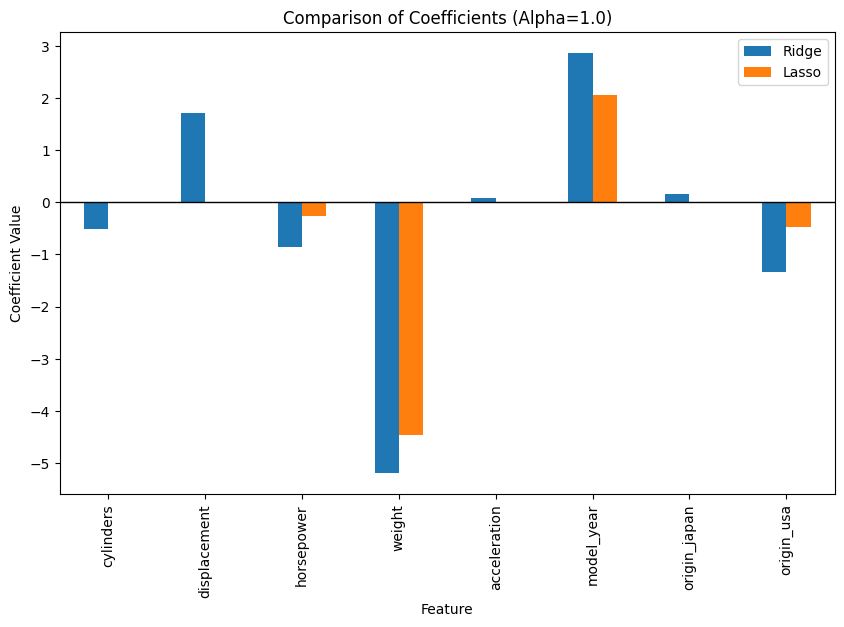

In [16]:
coef_df = pd.DataFrame({'Feature': X.columns, 'Ridge': ridge.coef_, 'Lasso': lasso.coef_})

print("\nCoefficients:\n")
print(coef_df)

coef_df.set_index('Feature').plot(kind='bar', figsize=(10, 6))
plt.title(f"Comparison of Coefficients (Alpha={alpha_val})")
plt.axhline(0, color='black', lw=1)
plt.ylabel("Coefficient Value")
plt.show()

##### 5. Report R² for training and testing

In [17]:
print(f"R² Scores (Alpha={alpha_val}):\n")
print(f"Ridge Train: {ridge.score(X_train_scaled, y_train):.4f} -- Test: {ridge.score(X_test_scaled, y_test):.4f}")
print(f"Lasso Train: {lasso.score(X_train_scaled, y_train):.4f} -- Test: {lasso.score(X_test_scaled, y_test):.4f}")

R² Scores (Alpha=1.0):

Ridge Train: 0.8286 -- Test: 0.7912
Lasso Train: 0.7961 -- Test: 0.8054
